In [154]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

In [155]:
df = pd.read_csv("music_streams.csv")

In [156]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [157]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


## Monthly Streams (Millions)

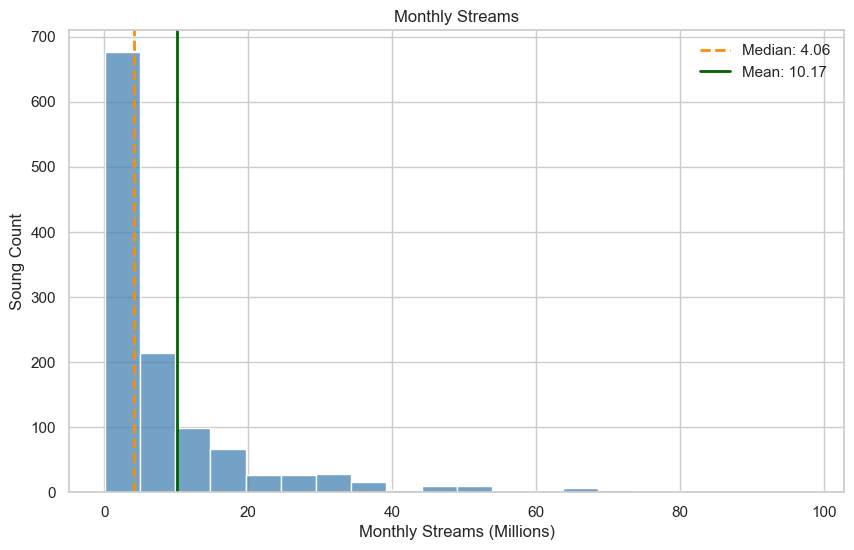

In [158]:
fig, ax = plt.subplots(figsize=(10, 6))
median = df.streams_millions.median()
mean = df.streams_millions.mean()
sns.histplot(data=df[df.streams_millions < 100], x='streams_millions', bins=20, ax=ax, color='steelblue')
ax.axvline(median, color='darkorange', linestyle='--', linewidth=2, label=f'Median: {median:.2f}')
ax.axvline(mean, color='darkgreen', linewidth=2, label=f'Mean: {mean:.2f}')
ax.legend(frameon=False)
ax.set_xlabel('Monthly Streams (Millions)')
ax.set_ylabel('Soung Count')
ax.set_title('Monthly Streams')
plt.show()

## Loudness (dB) Distribution

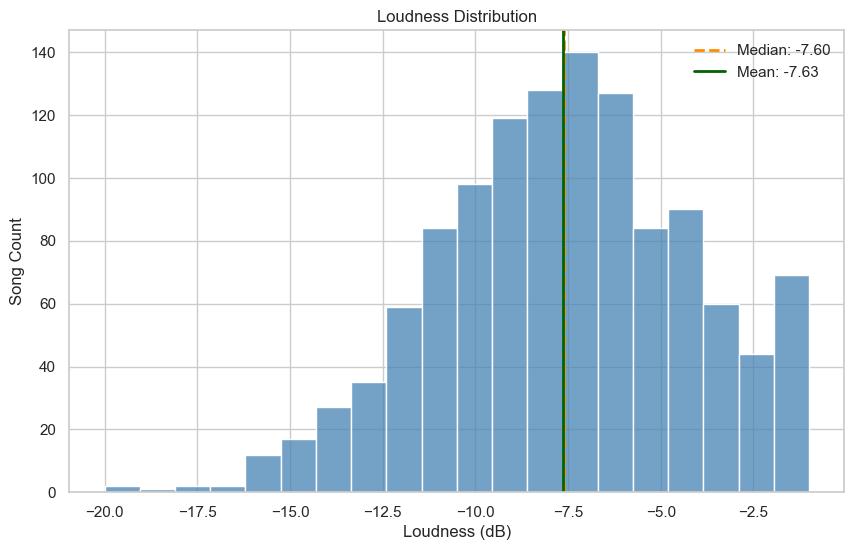

In [159]:
fig, ax = plt.subplots(figsize=(10, 6))
median = df.loudness_db.median()
mean = df.loudness_db.mean()
sns.histplot(data=df[df.loudness_db < 100], x='loudness_db', bins=20, ax=ax, color='steelblue')
ax.axvline(median, color='darkorange', linestyle='--', linewidth=2, label=f'Median: {median:.2f}')
ax.axvline(mean, color='darkgreen', linewidth=2, label=f'Mean: {mean:.2f}')
ax.legend(frameon=False)
ax.set_xlabel('Loudness (dB)')
ax.set_ylabel('Song Count')
ax.set_title('Loudness Distribution')
plt.show()

## Boxplots

In [160]:
order = df.groupby("genre")["energy"].median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='str', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

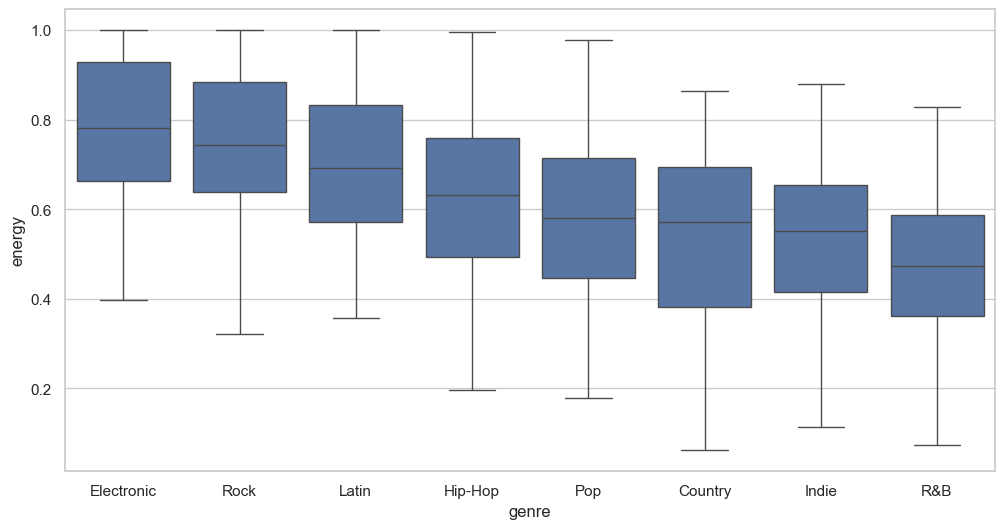

In [161]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x="genre", y="energy", order=order, ax=ax)

<Axes: xlabel='genre', ylabel='monthly_listeners'>

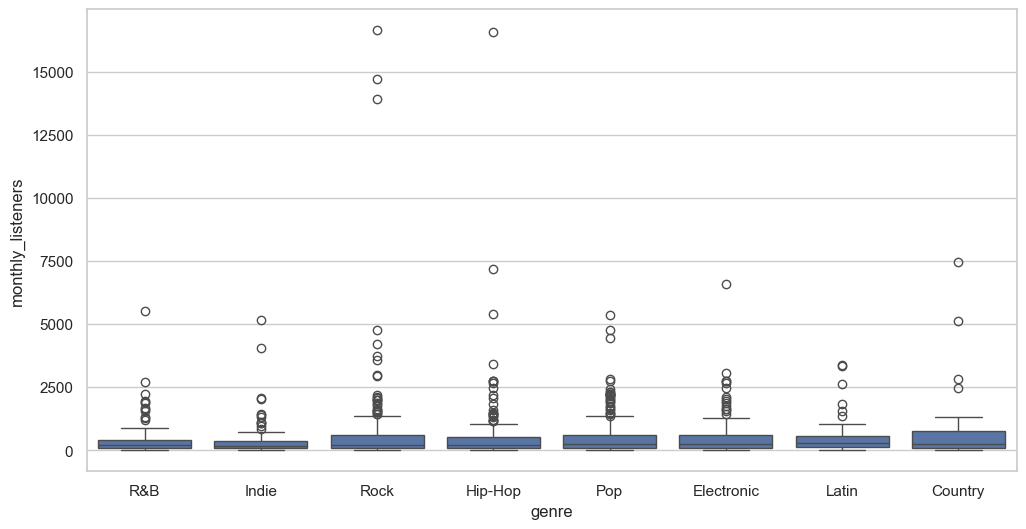

In [162]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x="genre", y="monthly_listeners", ax=ax)

<Axes: xlabel='genre', ylabel='monthly_listeners_log'>

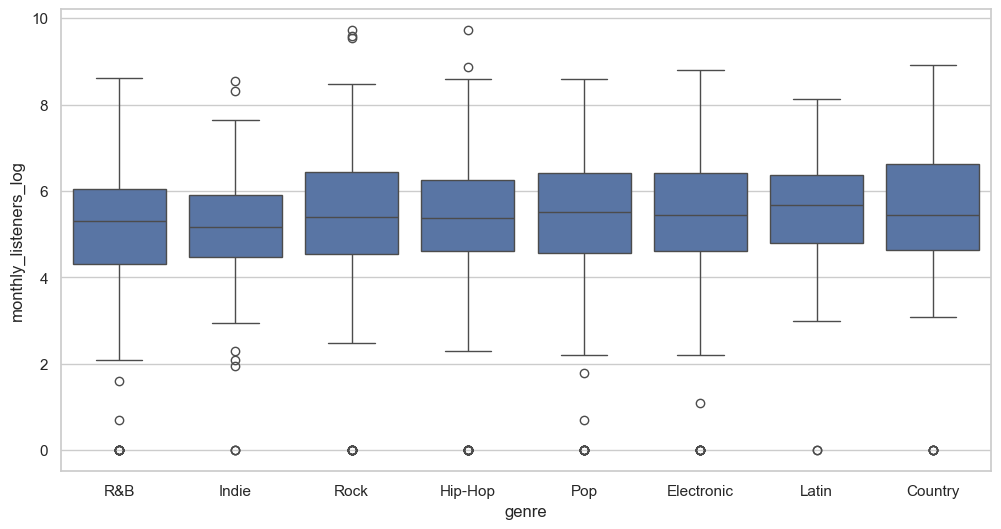

In [163]:

fig, ax = plt.subplots(figsize=(12, 6))

# create a new column with log-transformed monthly listeners
df['monthly_listeners_log'] = np.log(df['monthly_listeners'])

## OR set the y-axis to log scale
# ax.set_yscale('log')

sns.boxplot(data=df, x="genre", y="monthly_listeners_log", ax=ax)

## Scatterplot

<Axes: xlabel='energy', ylabel='danceability'>

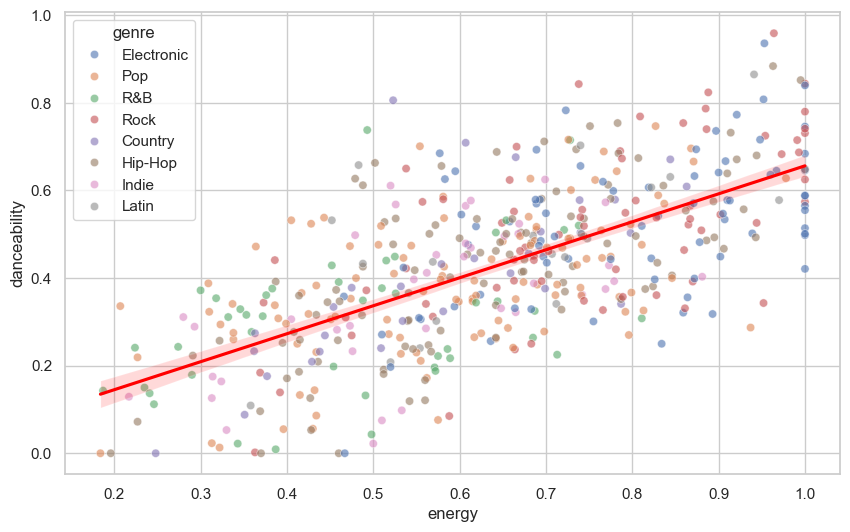

In [164]:
sample = df.sample(500, random_state=42) # random sample of the data
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=sample, x='energy', hue='genre', y='danceability', alpha=0.6)
sns.regplot(data=sample, x='energy', y='danceability', scatter=False, color='red')

Not a usuable chart, create separate ones for each genre.

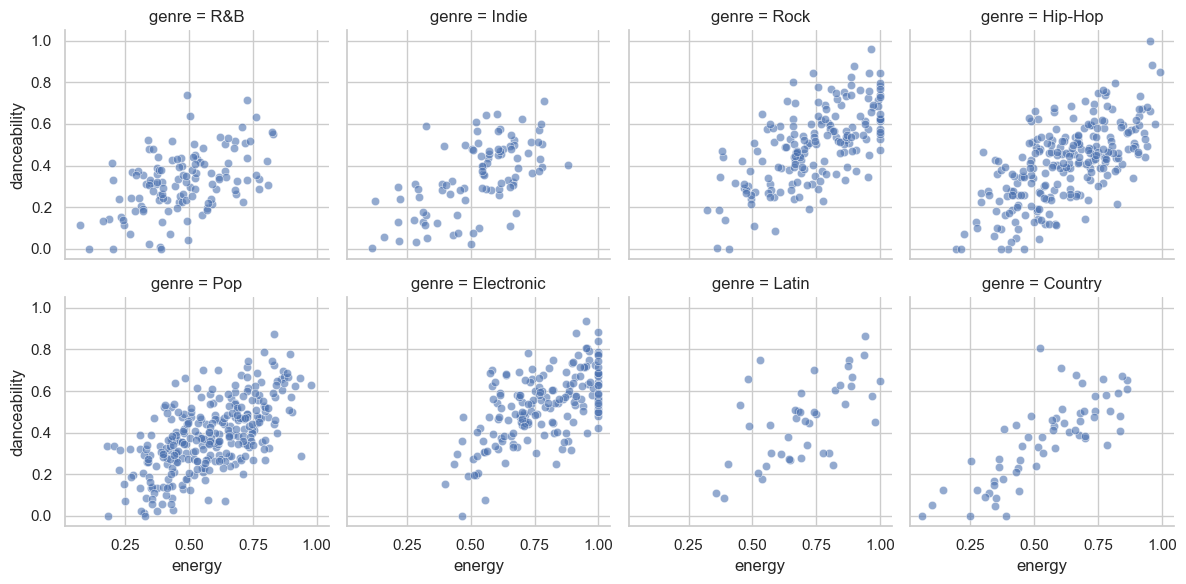

In [165]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability", alpha=0.6)

<Axes: xlabel='energy', ylabel='monthly_listeners'>

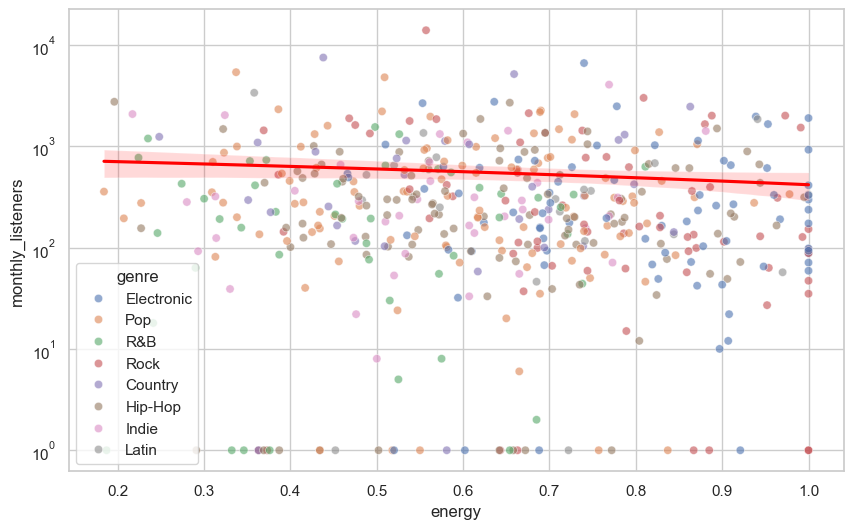

In [166]:
sample = df.sample(500, random_state=42) # random sample of the data
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale('log')
sns.scatterplot(data=sample, x='energy', hue='genre', y='monthly_listeners', alpha=0.6)
sns.regplot(data=sample, x='energy', y='monthly_listeners', scatter=False, color='red')

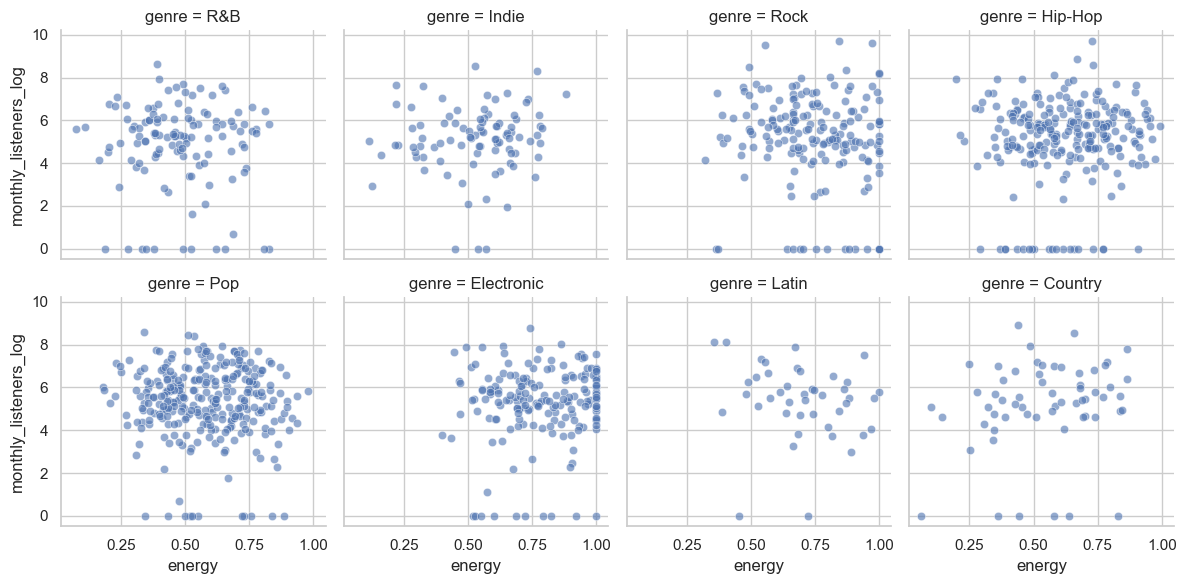

In [167]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "monthly_listeners_log", alpha=0.6)

## Temporal Visualizations (Line Charts and Friends)

In [168]:
pop_trend = df[df.genre == 'Pop'].groupby('year')['streams_millions'].median()
pop_trend

year
2015     7.160
2016     3.540
2017     3.560
2018    11.370
2019     4.720
2020     5.075
2021     3.645
2022     4.445
2023     4.230
2024     3.390
Name: streams_millions, dtype: float64

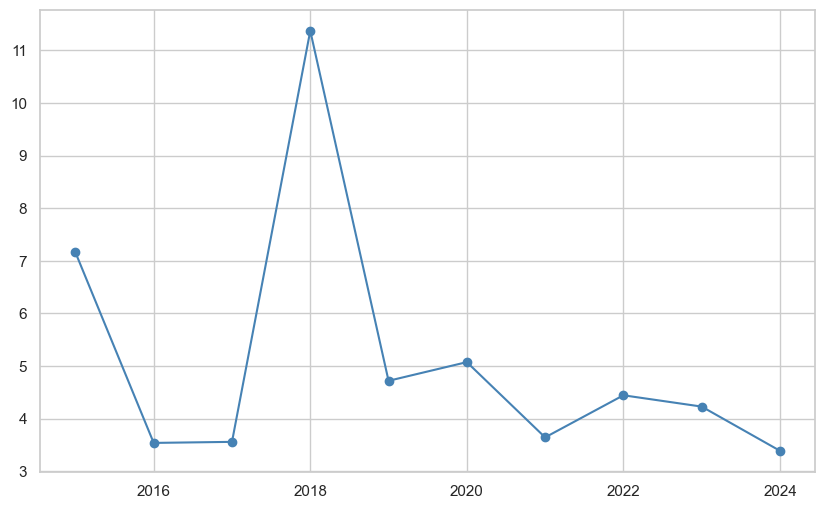

In [169]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pop_trend.index, pop_trend, marker='o', color='steelblue')

In [170]:
genres = ['Pop', 'Hip-Hop', 'Rock', 'Electronic', 'R&B', 'Country', 'Latin', 'Indie']

trend = df[df.genre.isin(genres)].groupby(['year', 'genre'])['streams_millions'].median().reset_index()
trend

,year,genre,streams_millions
0,2015,Country,8.850
1,2015,Electronic,6.040
2,2015,Hip-Hop,5.755
3,2015,Indie,13.900
4,2015,Pop,7.160
...,...,...,...
73,2024,Indie,3.420
74,2024,Latin,3.800
75,2024,Pop,3.390
76,2024,R&B,3.730


array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

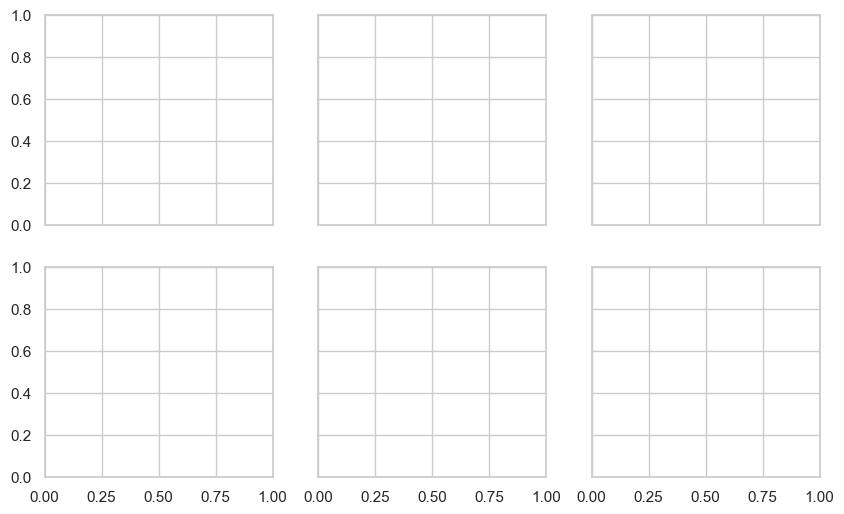

In [171]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes

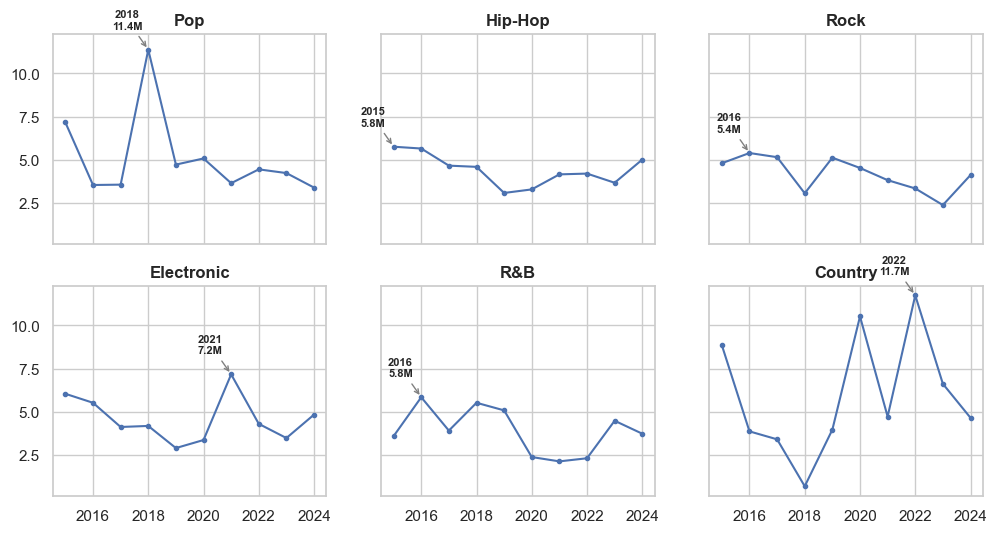

In [172]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    data = trend[trend.genre == genre]
    peak = data.loc[data.streams_millions.idxmax()]
    ax.annotate(f"{peak.year}\n{peak.streams_millions:.1f}M", 
                xy=(peak.year, peak.streams_millions), 
                xytext=(-15, 15),
                textcoords='offset points',
                ha='center', # horizontal alignment
                # can also add arrowprops
                arrowprops=dict(arrowstyle='->', color='gray', lw=1),
                fontsize=8, fontweight='bold')
    ax.plot(data.year, data.streams_millions, marker='o', ms=3)
    ax.set_title(genre, fontweight='bold')
    # ax.set_xlabel('Year')
    # ax.set_ylabel('Median Streams (Millions)')

In [173]:
labels = df['label'].unique()
print(labels)

<StringArray>
[             'AWAL',        'A24 Sounds',       'Dead Oceans',
        'Sony Music', 'Secretly Canadian',           'Sub Pop',
      'Warner Music',     'Beggars Group',       'Big Machine',
   'Universal Music',           'Concord',        'Interscope',
        'Jagjaguwar']
Length: 13, dtype: str


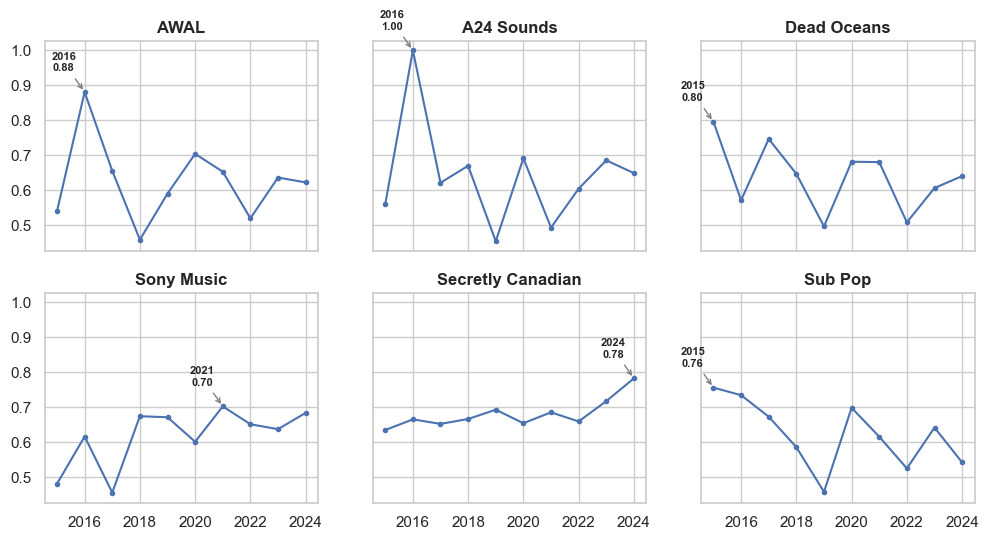

In [174]:
trend = df[df.label.isin(labels)].groupby(['year', 'label'])['energy'].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, label in zip(axes, labels):
    data = trend[trend.label == label]
    peak = data.loc[data.energy.idxmax()]
    ax.annotate(f"{peak.year}\n{peak.energy:.2f}", 
                xy=(peak.year, peak.energy), 
                xytext=(-15, 15),
                textcoords='offset points',
                ha='center', # horizontal alignment
                # can also add arrowprops
                arrowprops=dict(arrowstyle='->', color='gray', lw=1),
                fontsize=8, fontweight='bold')
    ax.plot(data.year, data.energy, marker='o', ms=3)
    ax.set_title(label, fontweight='bold')

## Altair Visualization

I am using stacked bar segments from altair to visualize the median number of streams by genre and year.

In [178]:
import altair as alt

selection = alt.selection_point(fields=['genre'], bind='legend')
trend = df.groupby(['year', 'genre'])['streams_millions'].median().reset_index()

alt.Chart(trend).mark_bar().transform_calculate(
    genre_order=f"if({selection.name}.genre && indexof({selection.name}.genre, datum.genre) !== -1, 0, 1)"
).encode(
    x=alt.X('year:O', title='Year'),
    y=alt.Y('streams_millions:Q', title='Median Streams (Millions)'),
    color=alt.Color('genre:N', title='Genre'),
    order='genre_order:N',
    opacity=alt.condition(selection, alt.value(0.9), alt.value(0.2)),
).add_params(
    selection
).properties(
    width=700,
    height=400,
    title='Median Monthly Streams by Genre and Year'
)

alt.Chart(...)